ANALISIS DE SENTIMIENTOS - OLIST REVIEWS

In [1]:
# =====================================================
# CONEXIÓN A LA BASE DE DATOS Y DEPENDENCIAS
# =====================================================

import pandas as pd
from sqlalchemy import create_engine, text
import ssl
from transformers import pipeline
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DB_USER = "nuclio"
DB_PASS = "nuclioTFM6"
DB_HOST = "nuclio.mysql.database.azure.com"
DB_NAME = "olist"

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:3306/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True,
    connect_args={"ssl": {"cert_reqs": ssl.CERT_NONE, "check_hostname": False}}
)

In [2]:
# =====================================================
# CARGA DE TABLA DE REVIEWS
# =====================================================

table = "olist_order_reviews_dataset"
query = f"SELECT * FROM `{table}`"

df = pd.read_sql_query(query, con=engine)
display(Markdown(f"### Tabla: `{table}`"))
display(df.head())

total_reviews = len(df)
reviews_with_text = df['review_comment_message'].notna().sum()

print(f"Total de reseñas: {total_reviews}")
print(f"Reseñas con comentario: {reviews_with_text}")
print(f"Porcentaje con comentario: {reviews_with_text / total_reviews:.1%}")

# =====================================================
# LIMPIEZA DE DATOS
# =====================================================

df = df.dropna(subset=["review_comment_message"])
print(f"Total de reseñas con texto: {len(df)}")

# =====================================================
# CARGA DEL MODELO DE SENTIMIENTOS (Hugging Face)
# =====================================================

print("Cargando modelo de análisis de sentimientos...")
sentiment_model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")


### Tabla: `olist_order_reviews_dataset`

,id,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18 00:00:00,2018-01-18 21:46:59
1,2,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10 00:00:00,2018-03-11 03:05:13
2,3,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17 00:00:00,2018-02-18 14:36:24
3,4,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,5,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Total de reseñas: 200
Reseñas con comentario: 82
Porcentaje con comentario: 41.0%
Total de reseñas con texto: 82
Cargando modelo de análisis de sentimientos...


Device set to use cpu


In [3]:
# =====================================================
# APLICACIÓN DEL MODELO
# =====================================================

def classify_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]
        label = result["label"]
        score = result["score"]
        if "1 star" in label or "2 stars" in label:
            category = "Negativo"
        elif "3 stars" in label:
            category = "Neutral"
        else:
            category = "Positivo"
        return pd.Series([label, score, category])
    except Exception:
        return pd.Series([None, None, "Error"])

df[["sentiment_label", "sentiment_score", "sentiment_category"]] = df["review_comment_message"].apply(classify_sentiment) # type: ignore

# =====================================================
# AÑADIR AÑO DEL COMENTARIO
# =====================================================

df["review_creation_date"] = pd.to_datetime(df["review_creation_date"], errors="coerce")
df["review_year"] = df["review_creation_date"].dt.year

# =====================================================
# RESULTADOS
# =====================================================

display(Markdown("### Vista previa de análisis de sentimientos con año"))
display(df[[
    "review_comment_message",
    "review_score",
    "sentiment_label",
    "sentiment_category",
    "sentiment_score",
    "review_year"
]].head(10))

print("\nDistribución general de sentimientos:")
print(df["sentiment_category"].value_counts())

### Vista previa de análisis de sentimientos con año

,review_comment_message,review_score,sentiment_label,sentiment_category,sentiment_score,review_year
3,Recebi bem antes do prazo estipulado.,5,3 stars,Neutral,0.399876,2017
4,Parabéns lojas lannister adorei comprar pela I...,5,5 stars,Positivo,0.538074,2018
9,aparelho eficiente. no site a marca do aparelh...,4,3 stars,Neutral,0.361089,2018
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,3 stars,Neutral,0.654753,2018
15,"Vendedor confiável, produto ok e entrega antes...",5,4 stars,Positivo,0.470945,2018
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2,1 star,Negativo,0.360026,2018
19,Péssimo,1,1 star,Negativo,0.955767,2018
22,Loja nota 10,5,5 stars,Positivo,0.442616,2018
24,obrigado pela atençao amim dispensada,5,1 star,Negativo,0.444979,2017
27,A compra foi realizada facilmente.\r\nA entreg...,5,5 stars,Positivo,0.554259,2018



Distribución general de sentimientos:
sentiment_category
Positivo    43
Negativo    27
Neutral     12
Name: count, dtype: int64


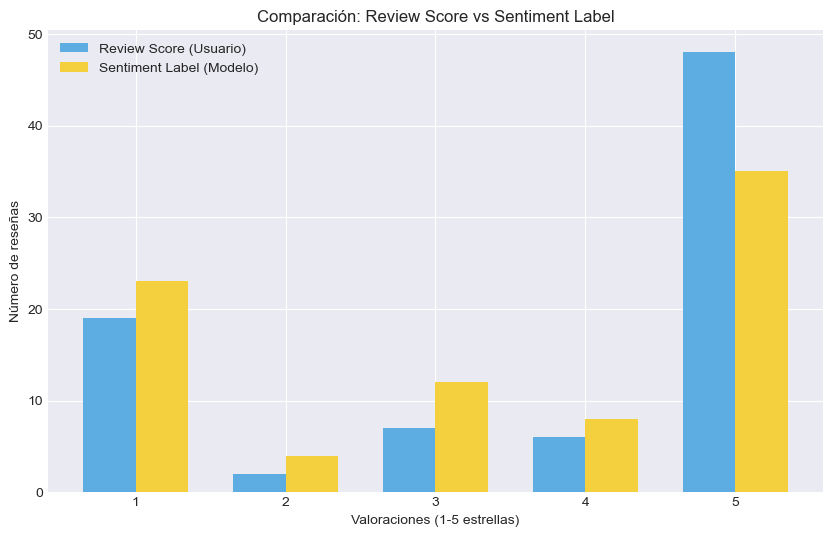

In [4]:
# -----------------------------------------------------
# 1️⃣ Gráfico de barras: review_score vs sentiment_label
# -----------------------------------------------------

plt.style.use('seaborn-v0_8-darkgrid')  # estilo agradable

plt.figure(figsize=(10,6))

# Contamos frecuencia de review_score y sentiment_label
review_counts = df['review_score'].value_counts().sort_index()
sentiment_counts = (
    df['sentiment_label']
    .str.extract(r'(\d)')[0]  # extraer el número de estrellas del label
    .astype(float)
    .value_counts()
    .sort_index()
)

x = np.arange(1,6)
width = 0.35

plt.bar(x - width/2, review_counts.reindex(x, fill_value=0), width, label='Review Score (Usuario)', color='#5DADE2')
plt.bar(x + width/2, sentiment_counts.reindex(x, fill_value=0), width, label='Sentiment Label (Modelo)', color='#F4D03F')

plt.xlabel('Valoraciones (1-5 estrellas)')
plt.ylabel('Número de reseñas')
plt.title('Comparación: Review Score vs Sentiment Label')
plt.legend()
plt.xticks(x)
plt.show()

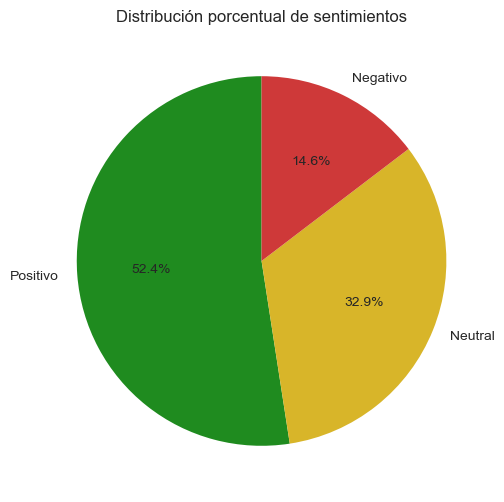

In [12]:
# -----------------------------------------------------
# 2️⃣ Gráfico circular: distribución de sentimientos
# -----------------------------------------------------
plt.figure(figsize=(6,6))
colors = ["#1F8B1F","#D8B529","#CE3939"]

df['sentiment_category'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, colors=colors,
    labels=['Positivo', 'Neutral', 'Negativo']
)
plt.title("Distribución porcentual de sentimientos")
plt.ylabel('')
plt.show()

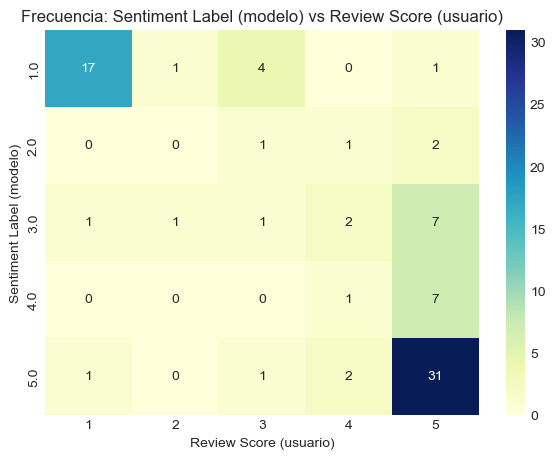

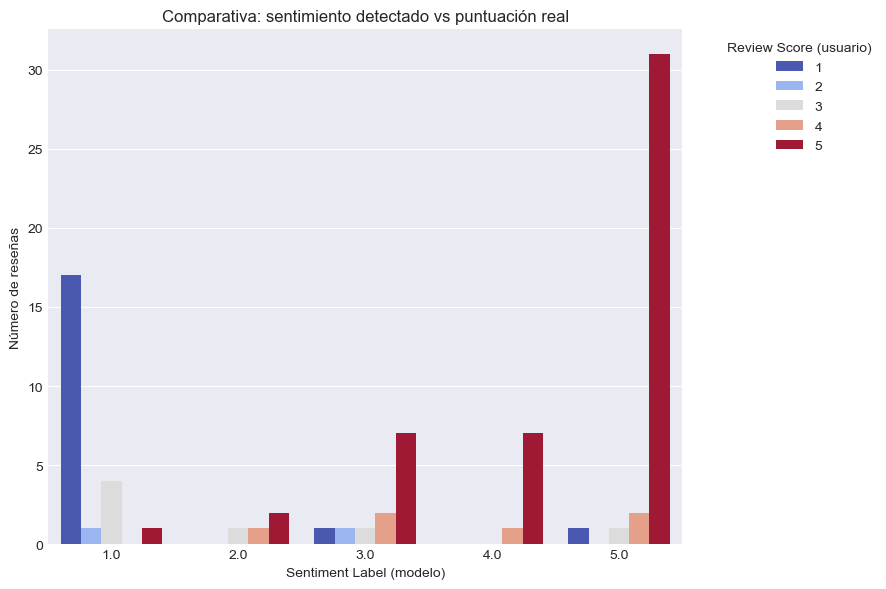

In [6]:
# -----------------------------------------------------
# 3️⃣ Dispersión recomendada: Sentiment Label vs Review Score
# -----------------------------------------------------
# Convertimos sentiment_label (ej: "4 stars") en número


# Convertir a número
df['sentiment_label_num'] = df['sentiment_label'].str.extract(r'(\d)')[0].astype(float)

# Crear tabla cruzada
heatmap_data = pd.crosstab(df['sentiment_label_num'], df['review_score'])

plt.figure(figsize=(7,5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Frecuencia: Sentiment Label (modelo) vs Review Score (usuario)')
plt.xlabel('Review Score (usuario)')
plt.ylabel('Sentiment Label (modelo)')
plt.show()

df_grouped = df.groupby(['sentiment_label_num', 'review_score']).size().reset_index(name='count')

plt.figure(figsize=(9,6))
sns.barplot(data=df_grouped, x='sentiment_label_num', y='count', hue='review_score', palette='coolwarm')
plt.title('Comparativa: sentimiento detectado vs puntuación real')
plt.xlabel('Sentiment Label (modelo)')
plt.ylabel('Número de reseñas')
plt.legend(title='Review Score (usuario)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

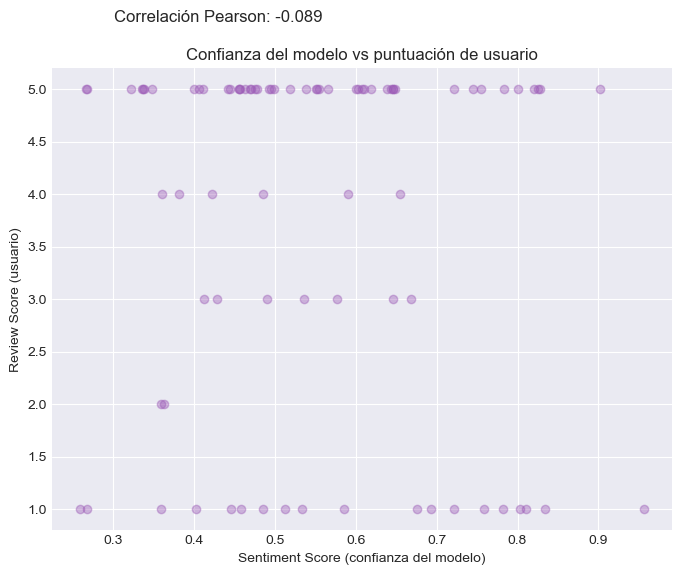

In [7]:
# -----------------------------------------------------
# 4️⃣ Correlación: Sentiment Score vs Review Score
# -----------------------------------------------------



plt.figure(figsize=(8,6))
plt.scatter(df['sentiment_score'], df['review_score'], alpha=0.4, color='#9B59B6')
plt.xlabel('Sentiment Score (confianza del modelo)')
plt.ylabel('Review Score (usuario)')
plt.title('Confianza del modelo vs puntuación de usuario')

# Calculamos correlación numérica
corr = df[['sentiment_score', 'review_score']].corr(method='pearson').iloc[0,1]
plt.text(0.1, 1.1, f'Correlación Pearson: {corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.show()


In [8]:
# -----------------------------------------------------
# 1️⃣ Unir con la tabla de órdenes para obtener tiempos de entrega
# -----------------------------------------------------
orders = pd.read_sql_query("SELECT order_id, order_purchase_timestamp, order_delivered_customer_date, order_estimated_delivery_date FROM olist_orders_dataset", con=engine)

# Convertir a fechas
for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col])

# Calcular tiempos
orders["delivery_time_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["delay_vs_estimated"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days

# Unir con el DataFrame de sentimientos
df_corr = df.merge(orders, on="order_id", how="left")

# -----------------------------------------------------
# 2️⃣ Unir con productos para obtener categorías
# -----------------------------------------------------
items = pd.read_sql_query("SELECT order_id, product_id FROM olist_order_items_dataset", con=engine)
products = pd.read_sql_query("SELECT product_id, product_category_name FROM olist_products_dataset", con=engine)
df_corr = df_corr.merge(items, on="order_id", how="left").merge(products, on="product_id", how="left")

# -----------------------------------------------------
# 3️⃣ Limpieza y preparación
# -----------------------------------------------------
df_corr = df_corr.dropna(subset=["sentiment_category"])
df_corr["delay_vs_estimated"] = df_corr["delay_vs_estimated"].fillna(0)


C:\Users\User\AppData\Local\Temp\ipykernel_18660\97101887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_corr, x="sentiment_category", y="delay_vs_estimated", palette="coolwarm")


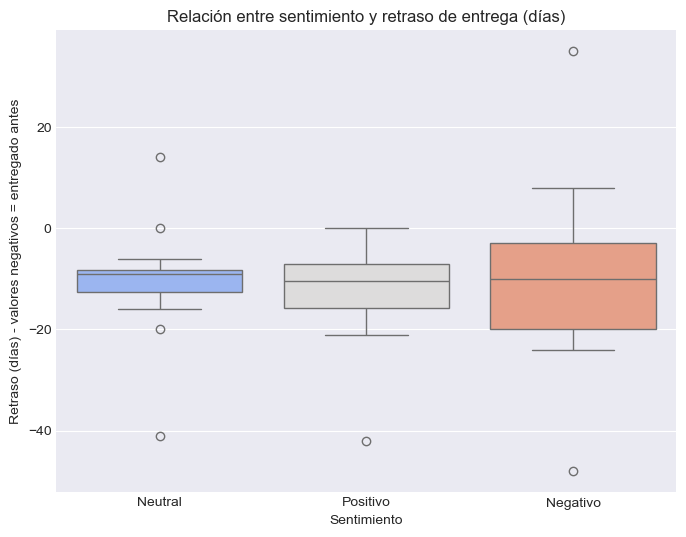

In [9]:
# -----------------------------------------------------
# 4️⃣ Relación: tiempo de entrega vs sentimiento
# -----------------------------------------------------
plt.figure(figsize=(8,6))
sns.boxplot(data=df_corr, x="sentiment_category", y="delay_vs_estimated", palette="coolwarm")
plt.title("Relación entre sentimiento y retraso de entrega (días)")
plt.xlabel("Sentimiento")
plt.ylabel("Retraso (días) - valores negativos = entregado antes")
plt.show()

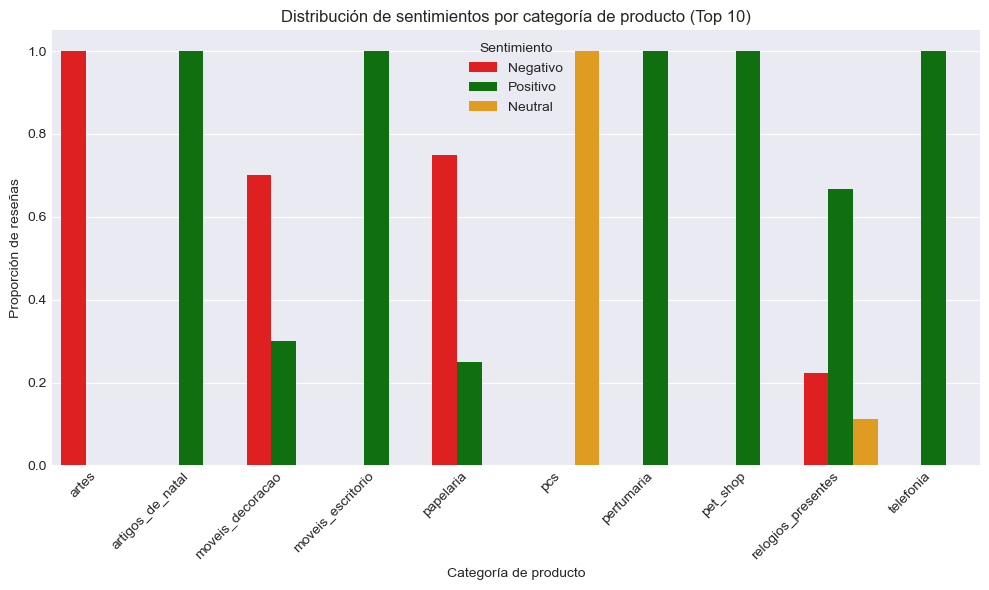

In [10]:
# -----------------------------------------------------
# 5️⃣ Relación: sentimiento por categoría de producto (colores personalizados)
# -----------------------------------------------------
sentiment_by_category = (
    df_corr.groupby("product_category_name")["sentiment_category"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

top_cats = (
    sentiment_by_category.groupby("product_category_name")["proportion"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

custom_palette = {
    "Negativo": "red",
    "Neutral": "orange",
    "Positivo": "green"
}

plt.figure(figsize=(10,6))
sns.barplot(
    data=sentiment_by_category[sentiment_by_category["product_category_name"].isin(top_cats)],
    x="product_category_name", 
    y="proportion", 
    hue="sentiment_category",
    palette=custom_palette
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribución de sentimientos por categoría de producto (Top 10)")
plt.xlabel("Categoría de producto")
plt.ylabel("Proporción de reseñas")
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()


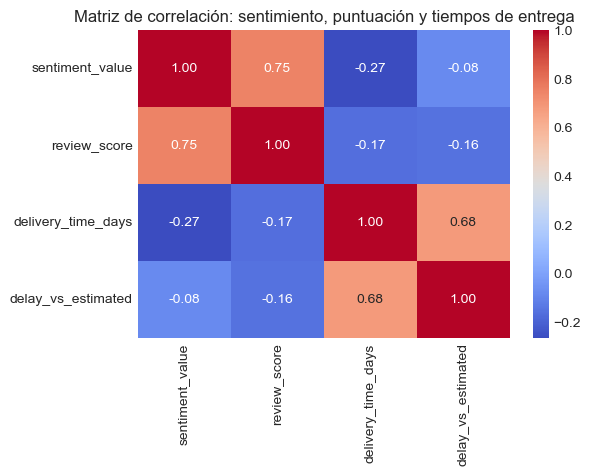

📊 Correlaciones principales:
sentiment_value       1.000000
review_score          0.751492
delay_vs_estimated   -0.082015
delivery_time_days   -0.265360
Name: sentiment_value, dtype: float64


In [11]:
# -----------------------------------------------------
# 6️⃣ Correlación numérica general
# -----------------------------------------------------
# Convertimos sentimientos a valores numéricos para correlación
sentiment_map = {"Negativo": 1, "Neutral": 3, "Positivo": 5}
df_corr["sentiment_value"] = df_corr["sentiment_category"].map(sentiment_map)

corr_matrix = df_corr[["sentiment_value", "review_score", "delivery_time_days", "delay_vs_estimated"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación: sentimiento, puntuación y tiempos de entrega")
plt.show()

# -----------------------------------------------------
# 7️⃣ Resumen textual
# -----------------------------------------------------
print("📊 Correlaciones principales:")
print(corr_matrix["sentiment_value"].sort_values(ascending=False))